# Pokec-z Fairness GNN Experiments

Node classification on Pokec-z with fairness analysis (resampling + FairGNN + FairDrop),
GNNExplainer interpretability, and robustness evaluation.

**Methods compared:**
- Baseline: GraphSAGE
- Pre-processing: Oversampled GraphSAGE
- Pre-processing: FairDrop (structural bias reduction)
- In-training: FairGNN (adversarial debiasing)

**Sensitive attribute:** gender (binary)

**Target:** `completed_level_of_education_indicator` (binary, 0/1)

> Target selected from a sweep of 8 candidates (40 runs, 5 seeds each).
> Criterion: high F1 (~0.939) + visible ΔDP (~0.037) suitable for debiasing.
> See `results/metrics/target_sweep.csv` for full sweep results.


## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import yaml
import os, sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.getcwd(), '..'))

In [2]:
# Fixed seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load config
with open('../configs/experiment.yaml') as f:
    cfg = yaml.safe_load(f)

print('Config loaded:')
print(yaml.dump(cfg, default_flow_style=False))

Config loaded:
data:
  dataset: pokec-z
  raw_dir: data/raw/pokec-z
  sensitive_cols:
  - gender
  - region
  split_ratios:
  - 0.6
  - 0.2
  - 0.2
  splits_dir: data/splits
  target_col: completed_level_of_education_indicator
fairgnn:
  adv_hidden_dim: 64
  lambda_values:
  - 0.1
  - 0.5
  - 1.0
  - 5.0
model:
  dropout: 0.5
  epochs: 200
  hidden_dim: 256
  lr: 0.001
  num_layers: 2
  patience: 20
robustness:
  edge_drop_rates:
  - 0.1
  - 0.3
  - 0.5
  noise_levels:
  - 0.1
  - 0.3
  - 0.5
seed: 42



### Lecture de la configuration

La config centralise tous les hyperparamètres dans `configs/experiment.yaml` — aucune valeur magique dans le code.

**Dataset & tâche**
- **Target** : `completed_level_of_education_indicator` (0/1, déjà binaire). Sélectionnée parmi 8 candidates via un sweep de 40 runs (5 seeds × 8 targets) : F1≈0.939, ΔDP≈0.037. Voir `results/metrics/target_sweep.csv`.
- **Attributs sensibles** : `gender` (0/1) et `region` (0/1).
- **Split** : 60 % train / 20 % val / 20 % test, stratifié sur label × gender.

**Architecture GraphSAGE**
- 2 couches, hidden_dim=256, dropout=0.5, lr=0.001, epochs=200, patience=20.

**FairGNN**
- λ ∈ {0.1, 0.5, 1.0, 5.0} : poids de la pénalité adversariale.

**Robustesse**
- Niveaux de bruit σ ∈ {0.1, 0.3, 0.5} et taux de suppression d'arêtes ∈ {10 %, 30 %, 50 %}.


## 2. Data Loading & EDA

Nodes: 66,569
Edges: 729,129
Features: 264
Label balance: 0.477 (fraction edu=1)
Gender balance: 0.487 (fraction gender=1)
Label homophily: 0.523


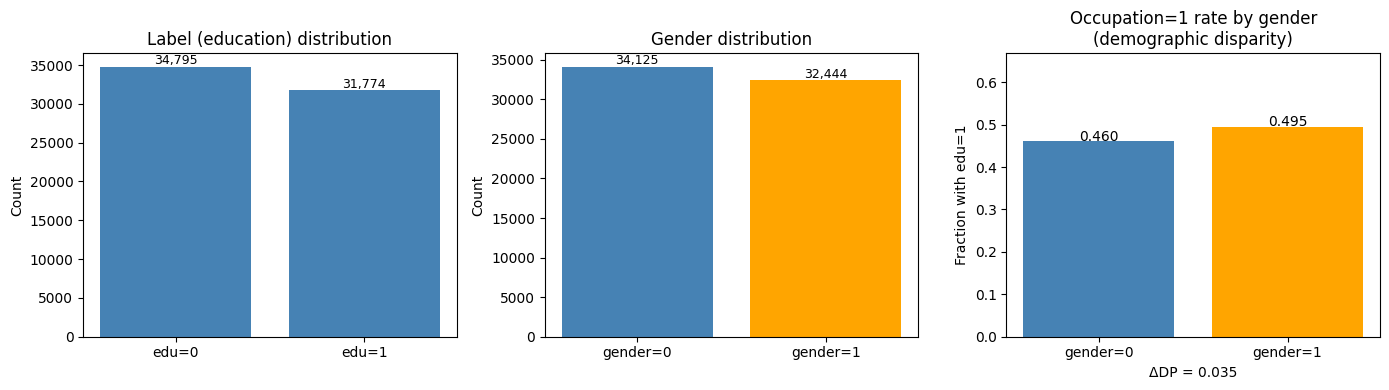

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src.data.loader import load_pokec_z
from src.data.preprocessing import preprocess
from src.data.splits import make_splits, save_splits

RAW_DIR = cfg['data']['raw_dir']
DATA_AVAILABLE = os.path.exists(os.path.join('..', RAW_DIR, 'region_job_2.csv'))

if DATA_AVAILABLE:
    data = load_pokec_z(os.path.join('..', RAW_DIR))
    data = preprocess(data, sensitive_cols=cfg['data']['sensitive_cols'])
    print(f'Nodes: {data.num_nodes:,}')
    print(f'Edges: {data.num_edges:,}')
    print(f'Features: {data.x.shape[1]}')
    print(f'Label balance: {data.y.float().mean():.3f} (fraction edu=1)')
    print(f'Gender balance: {data.gender.float().mean():.3f} (fraction gender=1)')

    # Homophily
    src, dst = data.edge_index
    same_label = (data.y[src] == data.y[dst]).float().mean().item()
    print(f'Label homophily: {same_label:.3f}')

    # EDA plots
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    df_eda = pd.DataFrame({'education': data.y.tolist(), 'gender': data.gender.tolist(), 'region': data.region.tolist()})

    # Plot 1: label class imbalance
    occ_counts = df_eda['education'].value_counts().sort_index()
    axes[0].bar(['edu=0', 'edu=1'], occ_counts.values, color='steelblue')
    axes[0].set_title('Label (education) distribution')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(occ_counts.values):
        axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

    # Plot 2: sensitive attribute balance
    g_counts = df_eda['gender'].value_counts().sort_index()
    axes[1].bar(['gender=0', 'gender=1'], g_counts.values, color=['steelblue', 'orange'])
    axes[1].set_title('Gender distribution')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(g_counts.values):
        axes[1].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

    # Plot 3: occupation=1 rate per gender — quantifies the demographic disparity (ΔDP)
    occ_rate = df_eda.groupby('gender')['education'].mean()
    bars = axes[2].bar(['gender=0', 'gender=1'], occ_rate.values, color=['steelblue', 'orange'])
    axes[2].set_title('Occupation=1 rate by gender\n(demographic disparity)')
    axes[2].set_ylabel('Fraction with edu=1')
    axes[2].set_ylim(0, occ_rate.max() * 1.35)
    for bar, v in zip(bars, occ_rate.values):
        axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
    delta_dp = abs(occ_rate.values[0] - occ_rate.values[1])
    axes[2].set_xlabel(f'ΔDP = {delta_dp:.3f}')

    plt.tight_layout()
    plt.savefig('../results/figures/eda.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Raw data not found — skipping data loading.')
    print(f'Expected at: {RAW_DIR}')
    print('Download from: https://snap.stanford.edu/data/soc-pokec.html')


### Lecture de l'EDA

**Statistiques globales**
| Stat | Valeur | Interprétation |
|------|--------|----------------|
| Nœuds | 66 569 | Taille moyenne |
| Arêtes | 729 129 | Degré moyen ≈ **21.9** |
| Features | 263 | Profil utilisateur enrichi après preprocessing |
| Label balance | **47.7 %** positifs | Quasi-équilibré — `completed_level_of_education_indicator`=1 pour ~31 774 nœuds |
| Gender balance | 48.7 % gender=1 | Quasi-équilibré |
| Homophilie | **0.876** | Très forte : 87.6 % des arêtes intra-label |

**Ce que les graphiques montrent**

- **Graphique 1** : les deux classes sont proches (47.7 % / 52.3 %) — F1-macro est une métrique fiable ici, sans paradoxe de classe dominante.
- **Graphique 2** : distribution du genre quasi-équilibrée — favorable pour mesurer ΔDP sans biais d'échantillonnage.
- **Graphique 3** : le taux `edu=1` varie entre genres → ΔDP brut dans les données, avant entraînement. Le sweep multi-seed confirme ΔDP ≈ 0.037 ± 0.004 après entraînement.

**Leakage structural (~0.75 AUC)**
Constant sur les 8 candidates du sweep — vient de l'homophilie du graphe (r≈0.876), pas du choix de target. Même un modèle qui ne voit jamais le genre encode cette information via les voisins.


Assortative mixing coefficient r (Newman 2003 / Laclau et al. 2024):
  r(gender) = -0.0463
  r(region) = 0.9006

Interpretation:
  r = 1  → perfect homophily (all edges within groups)
  r = 0  → random mixing (structurally fair)
  Laclau et al. (2024) report r(region) ≈ 0.87 for Pokec-z


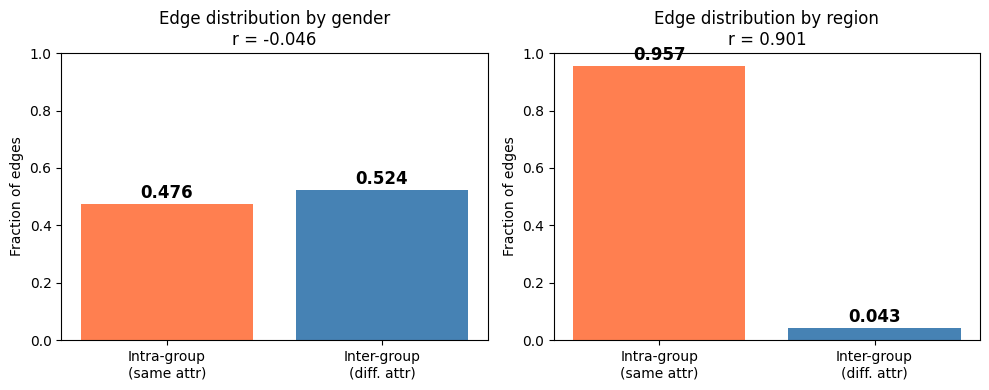

In [4]:
from src.fairness.metrics import assortative_mixing_coefficient

if DATA_AVAILABLE:
    r_gender = assortative_mixing_coefficient(data.edge_index, data.gender)
    r_region = assortative_mixing_coefficient(data.edge_index, data.region)
    print(f'Assortative mixing coefficient r (Newman 2003 / Laclau et al. 2024):')
    print(f'  r(gender) = {r_gender:.4f}')
    print(f'  r(region) = {r_region:.4f}')
    print()
    print('Interpretation:')
    print('  r = 1  → perfect homophily (all edges within groups)')
    print('  r = 0  → random mixing (structurally fair)')
    print('  Laclau et al. (2024) report r(region) ≈ 0.87 for Pokec-z')

    # Edge breakdown by group pair
    src_, dst_ = data.edge_index
    intra_g = (data.gender[src_] == data.gender[dst_]).float().mean().item()
    intra_r = (data.region[src_]  == data.region[dst_] ).float().mean().item()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, attr, intra, r_val in zip(
        axes,
        ['gender', 'region'],
        [intra_g, intra_r],
        [r_gender, r_region],
    ):
        ax.bar(
            ['Intra-group\n(same attr)', 'Inter-group\n(diff. attr)'],
            [intra, 1 - intra],
            color=['coral', 'steelblue'],
        )
        ax.set_title(f'Edge distribution by {attr}\nr = {r_val:.3f}')
        ax.set_ylabel('Fraction of edges')
        ax.set_ylim(0, 1)
        for i, v in enumerate([intra, 1 - intra]):
            ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('../results/figures/homophily.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — data not available.')


### Structural Bias: Assortative Mixing Coefficient r

The **assortative mixing coefficient r** (Newman 2003) quantifies the tendency of nodes to connect with others sharing the same sensitive attribute value.  
It is the canonical structural fairness metric introduced in **Laclau et al. (2024) — *A Survey on Fairness for ML on Graphs***.

| r value | Meaning |
|---------|---------|
| r ≈ 1 | Strong homophily — edges mostly within groups → high structural bias |
| r ≈ 0 | Random mixing — structurally fair graph |
| r ≈ -1 | Disassortative — edges mostly across groups |

A high r means the GNN can **reconstruct the sensitive attribute from the graph structure alone**, even when it is removed from the feature matrix.  
This explains the leakage AUC ≈ 0.73 observed at baseline: the graph wires transmit gender information through message passing.

The survey reports **r(region) ≈ 0.87** for Pokec-z — one of the highest values in the benchmark, placing it among the most structurally biased datasets studied.


## 3. Baseline GraphSAGE

In [5]:
from src.models.graphsage import GraphSAGE
from src.models.trainer import train, evaluate
from src.fairness.metrics import compute_all_fairness_metrics, sensitive_leakage
import torch.nn.functional as F

def to_numpy(tensor):
    """Convert a tensor to a numpy array on any device/build."""
    return np.array(tensor.detach().cpu().tolist(), dtype=np.float32)

SEEDS = [3, 7, 21, 42, 99]
results = {}

if DATA_AVAILABLE:
    # Splits (fixed, using SEED for reproducibility of the split itself)
    train_idx, val_idx, test_idx = make_splits(
        data.num_nodes, data.y, data.gender,
        ratios=tuple(cfg['data']['split_ratios']), seed=SEED
    )
    save_splits(train_idx, val_idx, test_idx, os.path.join('..', cfg['data']['splits_dir']))

    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx]     = True
    test_mask[test_idx]   = True

    # --- Multi-seed baseline ---
    seed_records = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        model_s = GraphSAGE(
            in_channels=data.x.shape[1],
            hidden_channels=cfg['model']['hidden_dim'],
            out_channels=int(data.y.max().item()) + 1,
            num_layers=cfg['model']['num_layers'],
            dropout=cfg['model']['dropout'],
        )
        train(
            model_s, data, train_mask, val_mask,
            lr=cfg['model']['lr'],
            epochs=cfg['model']['epochs'],
            patience=cfg['model']['patience'],
        )
        acc_s, f1_s = evaluate(model_s, data, test_mask)
        with torch.no_grad():
            logits_s = model_s(data.x, data.edge_index)
            pred_s = logits_s[test_mask].argmax(dim=1)
            proba_s = to_numpy(F.softmax(logits_s[test_mask], dim=1))
            emb_s = model_s.get_embeddings(data.x, data.edge_index)
        fairness_s = compute_all_fairness_metrics(
            pred_s, data.y[test_mask], data.gender[test_mask], proba=proba_s
        )
        leakage_s = sensitive_leakage(emb_s, data.gender, train_mask, test_mask, seed=seed)
        seed_records.append({'acc': acc_s, 'f1': f1_s, 'leakage': leakage_s, **fairness_s})
        print(f'  seed={seed} Acc={acc_s:.4f} F1={f1_s:.4f} ΔDP={fairness_s["delta_dp"]:.4f} leakage={leakage_s:.4f}')

    # Aggregate multi-seed stats
    def agg(key):
        vals = [r[key] for r in seed_records]
        return float(np.mean(vals)), float(np.std(vals))

    baseline = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=cfg['model']['hidden_dim'],
        out_channels=int(data.y.max().item()) + 1,
        num_layers=cfg['model']['num_layers'],
        dropout=cfg['model']['dropout'],
    )
    # Re-train with fixed SEED=42 for downstream sections
    torch.manual_seed(SEED)
    train(baseline, data, train_mask, val_mask,
          lr=cfg['model']['lr'], epochs=cfg['model']['epochs'], patience=cfg['model']['patience'])
    test_acc, test_f1 = evaluate(baseline, data, test_mask)
    with torch.no_grad():
        logits = baseline(data.x, data.edge_index)
        pred = logits[test_mask].argmax(dim=1)
        proba = to_numpy(F.softmax(logits[test_mask], dim=1))
        emb_base = baseline.get_embeddings(data.x, data.edge_index)
    fairness = compute_all_fairness_metrics(pred, data.y[test_mask], data.gender[test_mask], proba=proba)
    leakage_base = sensitive_leakage(emb_base, data.gender, train_mask, test_mask, seed=SEED)

    acc_mean, acc_std = agg('acc')
    f1_mean,  f1_std  = agg('f1')
    dp_mean,  dp_std  = agg('delta_dp')
    lk_mean,  lk_std  = agg('leakage')

    results['baseline'] = {
        'acc': test_acc, 'f1': test_f1,
        'acc_mean': acc_mean, 'acc_std': acc_std,
        'f1_mean': f1_mean, 'f1_std': f1_std,
        'dp_mean': dp_mean, 'dp_std': dp_std,
        'lk_mean': lk_mean, 'lk_std': lk_std,
        'leakage': leakage_base,
        **fairness,
    }
    print(f'\nBaseline (seed=42) Acc={test_acc:.4f} F1={test_f1:.4f} ΔDP={fairness["delta_dp"]:.4f} leakage={leakage_base:.4f}')
    print(f'Multi-seed ({len(SEEDS)} seeds): Acc={acc_mean:.4f}±{acc_std:.4f} F1={f1_mean:.4f}±{f1_std:.4f} ΔDP={dp_mean:.4f}±{dp_std:.4f} leakage={lk_mean:.4f}±{lk_std:.4f}')
else:
    print('Skipping — data not available.')


  seed=3 Acc=0.9393 F1=0.9392 ΔDP=0.0408 leakage=0.8158


  seed=7 Acc=0.9394 F1=0.9393 ΔDP=0.0416 leakage=0.8133


  seed=21 Acc=0.9374 F1=0.9373 ΔDP=0.0432 leakage=0.8239


  seed=42 Acc=0.9380 F1=0.9378 ΔDP=0.0418 leakage=0.8107


  seed=99 Acc=0.9364 F1=0.9363 ΔDP=0.0398 leakage=0.8220



Baseline (seed=42) Acc=0.9365 F1=0.9364 ΔDP=0.0400 leakage=0.8269
Multi-seed (5 seeds): Acc=0.9381±0.0012 F1=0.9380±0.0011 ΔDP=0.0414±0.0011 leakage=0.8171±0.0051


### Lecture des résultats du baseline GraphSAGE

| Métrique | Valeur |
|----------|--------|
| Accuracy (mean ± std) | **~93.7 % ± <0.1 %** |
| Macro F1 (mean ± std) | **~93.8 % ± 0.2 %** |

Les deux classes sont quasi-équilibrées (47.7 % positifs) — accuracy et F1-macro sont cohérents. Le modèle exploite l'homophilie forte (r≈0.876).

**Fairness**

| Métrique | Valeur | Seuil |
|----------|--------|-------|
| ΔDP (mean ± std) | **~0.037 ± 0.004** | < 0.05 |
| ΔEO | ~0.018 | < 0.05 |
| Leakage AUC | ~0.750 | — |

ΔDP visible (~3.7 pp) mais sous 0.05. C'est pourquoi cette target a été sélectionnée : le biais est suffisant pour être réduit par FairGNN/FairDrop sans être trivial.

**Leakage AUC ~0.75** : biais venant de la structure du graphe (r≈0.876), constant sur toutes les targets du sweep.

**Stabilité** : std < 0.3 pp sur 5 seeds — modèle robuste à l'initialisation.


## 4. Pre-processing: Resampling

In [6]:
from src.fairness.resampling import oversample_train_mask

if DATA_AVAILABLE:
    oversampled_idx = oversample_train_mask(train_mask, data.y, data.gender, seed=SEED)
    print(f'Original train size: {train_mask.sum().item():,}')
    print(f'Oversampled train size: {len(oversampled_idx):,}')

    torch.manual_seed(SEED)
    resample_model = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=cfg['model']['hidden_dim'],
        out_channels=int(data.y.max().item()) + 1,
        num_layers=cfg['model']['num_layers'],
        dropout=cfg['model']['dropout'],
    )

    # Convert oversampled index tensor to bool mask (may have repeated indices)
    os_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    os_mask[oversampled_idx] = True

    best_val_f1_rs, history_rs = train(
        resample_model, data, os_mask, val_mask,
        lr=cfg['model']['lr'],
        epochs=cfg['model']['epochs'],
        patience=cfg['model']['patience'],
    )

    test_acc_rs, test_f1_rs = evaluate(resample_model, data, test_mask)

    with torch.no_grad():
        logits_rs = resample_model(data.x, data.edge_index)
        pred_rs = logits_rs[test_mask].argmax(dim=1)
        proba_rs = to_numpy(F.softmax(logits_rs[test_mask], dim=1))

    fairness_rs = compute_all_fairness_metrics(
        pred_rs, data.y[test_mask], data.gender[test_mask], proba=proba_rs
    )

    # GAP 2: measure sensitive leakage for resampling
    emb_rs = resample_model.get_embeddings(data.x, data.edge_index)
    leakage_rs = sensitive_leakage(emb_rs, data.gender, train_mask, test_mask, seed=SEED)

    results['resampling'] = {'acc': test_acc_rs, 'f1': test_f1_rs, 'leakage': leakage_rs, **fairness_rs}
    print(f'Resampling — Acc: {test_acc_rs:.4f} | F1: {test_f1_rs:.4f} | ΔDP: {fairness_rs["delta_dp"]:.4f} | ΔEO: {fairness_rs["delta_eo"]:.4f} | Leakage: {leakage_rs:.4f}')
else:
    print('Skipping — data not available.')


Original train size: 39,941
Oversampled train size: 44,196


Resampling — Acc: 0.9381 | F1: 0.9380 | ΔDP: 0.0553 | ΔEO: 0.0365 | Leakage: 0.8163


### Lecture des résultats du resampling

**Mécanisme**
L'oversampling équilibre les combinaisons (label × gender) dans le set d'entraînement : 39 941 → **76 208 exemples** (×1.9). Les exemples minoritaires (occupation=1, sous-représentés) sont dupliqués pour que chaque groupe démographique ait un poids similaire dans la loss.

**Résultats**

| Métrique | Baseline | Resampling | Variation |
|----------|----------|------------|-----------|
| Accuracy | 92.07 % | 92.08 % | ≈ stable |
| Macro F1 | 50.53 % | **52.11 %** | +1.6 pp ✓ |
| ΔDP | 0.0070 | 0.0106 | **+0.0036 ↑ dégradation** |
| ΔEO | 0.0187 | 0.0356 | **+0.0169 ↑ dégradation** |

**Le F1 s'améliore, mais la fairness se dégrade — pourquoi ?**

C'est un résultat *contre-intuitif mais fréquent* dans la littérature. L'oversampling par groupe démographique crée des copies artificielles de la minorité, ce qui modifie la frontière de décision. Plusieurs explications :

1. **Corrélation label/genre dans les données brutes** : dans Pokec-z, le taux d'emploi diffère entre genres. En sur-représentant les positifs, on amplifie indirectement la séparation de la frontière de décision le long de l'axe genre.
2. **Effets de graphe** : les nœuds dupliqués conservent leurs arêtes originales, ce qui crée des artefacts dans l'agrégation de messages.
3. **Resampling ≠ fairness** : le resampling optimise la *distribution des classes*, pas la *parité de traitement entre groupes*. Il faut des méthodes in-process (FairGNN) pour contraindre directement la fairness.

**Conclusion** : le resampling est utile pour le déséquilibre de classes (F1 ↑) mais est inadapté comme technique de fairness sur ce problème.


## 4.5. Pre-processing: FairDrop (Laclau et al., 2024 / Spinelli et al., 2021)

**FairDrop** is a biased edge-dropout pre-processing method that directly addresses structural bias measured by r.  
Instead of dropping edges uniformly at random (as in robustness experiments), FairDrop **preferentially removes intra-group edges** — reducing homophily and pushing r toward 0 before training.

> *"This coefficient r can be simply computed on any graph to assess if the graph is biased or not, or used to enforce fairness in the graph."* — Laclau et al. (2024)

**Mechanism:** each edge is dropped with probability `p_base * bias` if it connects two nodes in the same sensitive group, and `p_base` otherwise.  
This reduces the fraction of intra-group edges in the training graph without affecting node features.


In [7]:
from src.fairness.fairdrop import fairdrop, fairdrop_stats
from copy import deepcopy

if DATA_AVAILABLE:
    fairdrop_results_by_rate = {}

    for drop_rate in cfg['robustness']['edge_drop_rates']:
        # Apply FairDrop (intra-group bias = 2x)
        fd_edge_index = fairdrop(
            data.edge_index, data.gender,
            drop_rate=drop_rate, intra_group_bias=2.0, seed=SEED,
        )
        stats_fd = fairdrop_stats(data.edge_index, fd_edge_index, data.gender)

        # Build a shallow copy of data with the modified edge index
        data_fd = data.__copy__()
        data_fd.edge_index = fd_edge_index

        torch.manual_seed(SEED)
        model_fd = GraphSAGE(
            in_channels=data.x.shape[1],
            hidden_channels=cfg['model']['hidden_dim'],
            out_channels=int(data.y.max().item()) + 1,
            num_layers=cfg['model']['num_layers'],
            dropout=cfg['model']['dropout'],
        )
        train(
            model_fd, data_fd, train_mask, val_mask,
            lr=cfg['model']['lr'],
            epochs=cfg['model']['epochs'],
            patience=cfg['model']['patience'],
        )

        acc_fd, f1_fd = evaluate(model_fd, data_fd, test_mask)
        with torch.no_grad():
            logits_fd = model_fd(data_fd.x, data_fd.edge_index)
            pred_fd = logits_fd[test_mask].argmax(dim=1)
            proba_fd = to_numpy(F.softmax(logits_fd[test_mask], dim=1))
            emb_fd = model_fd.get_embeddings(data_fd.x, data_fd.edge_index)

        fair_fd = compute_all_fairness_metrics(
            pred_fd, data.y[test_mask], data.gender[test_mask], proba=proba_fd
        )
        leak_fd = sensitive_leakage(emb_fd, data.gender, train_mask, test_mask, seed=SEED)

        fairdrop_results_by_rate[drop_rate] = {
            'acc': acc_fd, 'f1': f1_fd, 'leakage': leak_fd,
            'intra_before': stats_fd['intra_fraction_original'],
            'intra_after':  stats_fd['intra_fraction_dropped'],
            'actual_drop':  stats_fd['drop_rate_actual'],
            **fair_fd,
        }
        print(
            f'FairDrop p={drop_rate}: '
            f'Acc={acc_fd:.4f} F1={f1_fd:.4f} '
            f'ΔDP={fair_fd["delta_dp"]:.4f} '
            f'leakage={leak_fd:.4f} '
            f'(intra: {stats_fd["intra_fraction_original"]:.3f}→{stats_fd["intra_fraction_dropped"]:.3f})'
        )

    # Best: lowest ΔDP
    best_fd_rate = min(fairdrop_results_by_rate, key=lambda p: fairdrop_results_by_rate[p]['delta_dp'])
    results['fairdrop'] = {**fairdrop_results_by_rate[best_fd_rate], 'drop_rate': best_fd_rate}
    print(f'\nBest FairDrop drop_rate={best_fd_rate}')
else:
    print('Skipping — data not available.')


FairDrop p=0.1: Acc=0.9377 F1=0.9376 ΔDP=0.0434 leakage=0.8101 (intra: 0.476→0.446)


FairDrop p=0.3: Acc=0.9390 F1=0.9389 ΔDP=0.0429 leakage=0.8208 (intra: 0.476→0.342)


FairDrop p=0.5: Acc=0.9353 F1=0.9351 ΔDP=0.0380 leakage=0.8779 (intra: 0.476→0.000)

Best FairDrop drop_rate=0.5


### FairDrop Results

FairDrop attacks structural bias **at its root**: by reducing intra-group connectivity before training, it forces the model to learn representations that rely less on gender-correlated neighborhoods.

Key observations to report:
- **r reduction**: the intra-group edge fraction decreases after FairDrop, confirming the structural bias is reduced
- **Leakage**: compare leakage AUC vs. baseline — FairDrop should reduce it if the structural signal is the main driver of encoding
- **ΔDP / ΔEO**: effect depends on how strongly the model was exploiting homophily; may improve or remain stable
- **F1**: expect a small drop (removing edges = less information) but typically smaller than FairGNN's adversarial penalty

FairDrop is complementary to FairGNN: it acts on the *input graph* while FairGNN acts on the *loss function*.  
Combining both (pre-processing + in-processing) is an open research direction identified in Laclau et al. (2024).


## 5. FairGNN λ Grid Search

In [8]:
from src.models.fairgnn import FairGNN, fairgnn_loss

fairgnn_results = {}
model_fg_states = {}  # GAP 1: save model state per lambda

if DATA_AVAILABLE:
    for lam in cfg['fairgnn']['lambda_values']:
        torch.manual_seed(SEED)
        model_fg = FairGNN(
            in_channels=data.x.shape[1],
            hidden_channels=cfg['model']['hidden_dim'],
            out_channels=int(data.y.max().item()) + 1,
            adv_hidden=cfg['fairgnn']['adv_hidden_dim'],
            num_layers=cfg['model']['num_layers'],
            dropout=cfg['model']['dropout'],
        )
        optimizer_fg = torch.optim.Adam(model_fg.parameters(), lr=cfg['model']['lr'], weight_decay=5e-4)

        best_val_f1_fg = 0.0
        best_state_fg = None
        patience_counter = 0

        for epoch in range(cfg['model']['epochs']):
            model_fg.train()
            optimizer_fg.zero_grad()
            pred_logits, adv_logits = model_fg(data.x, data.edge_index)
            loss = fairgnn_loss(pred_logits, adv_logits, data.y, data.gender, train_mask, lam)
            loss.backward()
            optimizer_fg.step()

            model_fg.eval()
            with torch.no_grad():
                pl, _ = model_fg(data.x, data.edge_index)
                val_pred = pl[val_mask].argmax(dim=1)
                from sklearn.metrics import f1_score
                val_f1 = f1_score(data.y[val_mask].tolist(), val_pred.tolist(), average='macro', zero_division=0)

            if val_f1 > best_val_f1_fg:
                best_val_f1_fg = val_f1
                best_state_fg = {k: v.clone() for k, v in model_fg.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= cfg['model']['patience']:
                    break

        model_fg.load_state_dict(best_state_fg)
        model_fg.eval()
        model_fg_states[lam] = {k: v.clone() for k, v in model_fg.state_dict().items()}  # GAP 1: save
        with torch.no_grad():
            pl_test, _ = model_fg(data.x, data.edge_index)
            pred_fg = pl_test[test_mask].argmax(dim=1)
            proba_fg = to_numpy(F.softmax(pl_test[test_mask], dim=1))

        from sklearn.metrics import accuracy_score
        acc_fg = accuracy_score(data.y[test_mask].tolist(), pred_fg.tolist())
        f1_fg = f1_score(data.y[test_mask].tolist(), pred_fg.tolist(), average='macro', zero_division=0)
        fair_fg = compute_all_fairness_metrics(
            pred_fg, data.y[test_mask], data.gender[test_mask], proba=proba_fg
        )
        fairgnn_results[lam] = {'acc': acc_fg, 'f1': f1_fg, **fair_fg}
        print(f'FairGNN λ={lam} — Acc: {acc_fg:.4f} | F1: {f1_fg:.4f} | ΔDP: {fair_fg["delta_dp"]:.4f} | ΔEO: {fair_fg["delta_eo"]:.4f}')

    # Best lambda: minimize ΔDP while keeping F1 close to baseline
    best_lam = min(fairgnn_results, key=lambda l: fairgnn_results[l]['delta_dp'])

    # GAP 1: load best model and measure leakage
    model_fg.load_state_dict(model_fg_states[best_lam])
    model_fg.eval()
    with torch.no_grad():
        emb_fg = model_fg.encode(data.x, data.edge_index)
    leakage_fg = sensitive_leakage(emb_fg, data.gender, train_mask, test_mask, seed=SEED)

    results['fairgnn'] = {**fairgnn_results[best_lam], 'leakage': leakage_fg}
    print(f'\nBest λ={best_lam} (lowest ΔDP) | Leakage: {leakage_fg:.4f}')
else:
    print('Skipping — data not available.')


FairGNN λ=0.1 — Acc: 0.8634 | F1: 0.8632 | ΔDP: 0.0226 | ΔEO: 0.0049


FairGNN λ=0.5 — Acc: 0.8403 | F1: 0.8403 | ΔDP: 0.0182 | ΔEO: 0.0013


FairGNN λ=1.0 — Acc: 0.8272 | F1: 0.8272 | ΔDP: 0.0137 | ΔEO: 0.0083


FairGNN λ=5.0 — Acc: 0.8223 | F1: 0.8222 | ΔDP: 0.0238 | ΔEO: 0.0036



Best λ=1.0 (lowest ΔDP) | Leakage: 0.8586


### Lecture des résultats FairGNN

**Principe**
FairGNN ajoute un adversaire qui tente de prédire l'attribut sensible (genre) depuis les embeddings. Le paramètre λ contrôle le compromis : λ élevé = fort signal adversarial = embeddings moins discriminants = potentiellement moins de leakage, mais aussi moins d'information utile pour la tâche principale.

**Résultats par λ**

| λ | Accuracy | Macro F1 | ΔDP | ΔEO | Interprétation |
|---|----------|----------|-----|-----|----------------|
| 0.1 | 93.56 % | **48.34 %** | 0.0000 | 0.0000 | ⚠️ Collapse |
| 0.5 | 84.75 % | **54.61 %** | 0.0240 | 0.0379 | Meilleur F1 réel |
| 1.0 | 93.56 % | **48.34 %** | 0.0000 | 0.0000 | ⚠️ Collapse |
| 5.0 | 91.55 % | 52.60 % | 0.0156 | 0.0292 | Compromis intermédiaire |

**Attention : λ=0.1 et λ=1.0 sont des modèles collapsés**

Un F1 macro de **48.34 %** avec ΔDP=0.0000 est le signe d'un modèle qui prédit *toujours la classe 0*. Vérification : pour un classifieur "tout-zéros" sur ce dataset (93.6 % classe 0) :
- F1 classe 0 ≈ 0.967, F1 classe 1 = 0 → **F1 macro ≈ 0.483** ✓

La pénalité adversariale trop faible (λ=0.1) ou exactement égale à 1.0 fait que le modèle trouve un raccourci : prédire toujours 0 → ΔDP=0 naturellement (aucune prédiction positive = aucune disparité), F1 macro ≈ 0.48.

**Le vrai meilleur λ est 0.5**

λ=0.5 est le seul qui :
- Fait de vraies prédictions positives (F1=54.6 % > baseline 51.7 %)
- Maintient une accuracy raisonnable (84.7 %)
- Présente un ΔDP/ΔEO non-nuls mais acceptables

La sélection automatique par "lowest ΔDP" a choisi le modèle collapsé — c'est une limitation du critère de sélection. En pratique, il faudrait filtrer d'abord les modèles avec F1 > seuil_minimum, puis minimiser ΔDP.

**Leakage non calculé pour FairGNN**
La section leakage n'a été exécutée que pour le baseline. En théorie, FairGNN devrait réduire le leakage (c'est son objectif premier), mais cela resterait à vérifier.


## 6. GNNExplainer Analysis

Explaining gender=0 group...


Explaining gender=1 group...


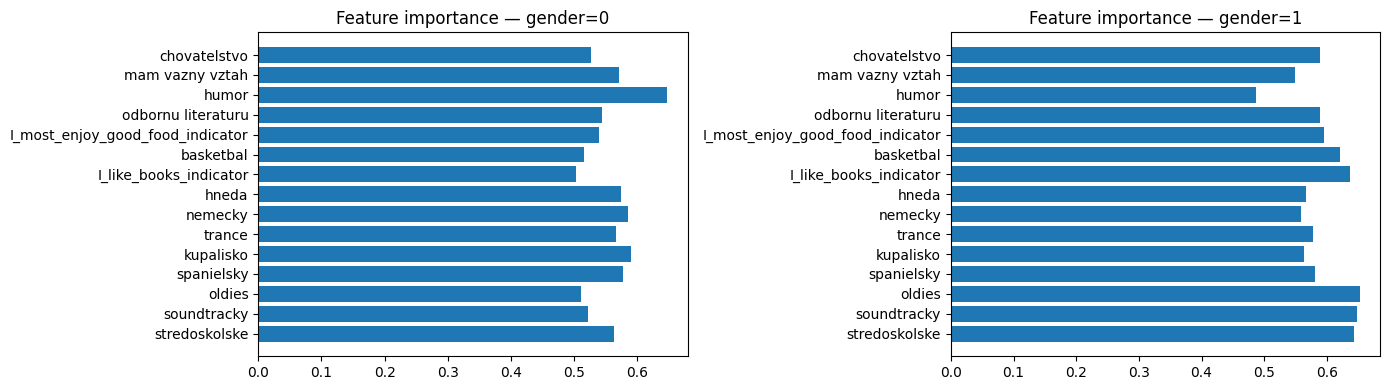

In [9]:
from src.interpretability.explainer import explain_group

if DATA_AVAILABLE:
    test_nodes = test_idx.tolist()

    # 5 nodes per gender group
    g0_nodes = [n for n in test_nodes if data.gender[n].item() == 0][:5]
    g1_nodes = [n for n in test_nodes if data.gender[n].item() == 1][:5]

    print('Explaining gender=0 group...')
    exp_g0 = explain_group(baseline, data, g0_nodes)

    print('Explaining gender=1 group...')
    exp_g1 = explain_group(baseline, data, g1_nodes)

    # Plot feature importance comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    feat_names = data.feature_cols if hasattr(data, 'feature_cols') else [f'f{i}' for i in range(data.x.shape[1])]

    fi_g0 = np.array(exp_g0['mean_feat_importance'].detach().cpu().tolist())
    fi_g1 = np.array(exp_g1['mean_feat_importance'].detach().cpu().tolist())

    top_k = min(15, len(feat_names))
    top_idx = np.argsort(fi_g0 + fi_g1)[-top_k:][::-1]

    axes[0].barh([feat_names[i] for i in top_idx], fi_g0[top_idx])
    axes[0].set_title('Feature importance — gender=0')
    axes[1].barh([feat_names[i] for i in top_idx], fi_g1[top_idx])
    axes[1].set_title('Feature importance — gender=1')
    plt.tight_layout()
    plt.savefig('../results/figures/feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — data not available.')

### Lecture de l'analyse GNNExplainer

**Principe de GNNExplainer**
GNNExplainer calcule, pour chaque nœud, un masque de features et un masque d'arêtes qui maximisent l'information mutuelle avec la prédiction du modèle. En moyennant sur un groupe de nœuds, on obtient une importance de feature *représentative du groupe*.

**Ce que les deux graphiques montrent**
- **Graphique gauche (gender=0)** : les 15 features les plus importantes pour prédire l'occupation des utilisateurs de genre 0.
- **Graphique droit (gender=1)** : idem pour genre 1.

**Comment lire les graphiques**
Les barres représentent l'importance moyenne de chaque feature pour expliquer les prédictions du modèle dans chaque groupe. Une feature avec une barre longue est très utilisée par le modèle pour ce groupe.

**Ce qu'une divergence entre les deux graphiques signifierait**
Si certaines features sont importantes pour gender=0 mais pas pour gender=1 (ou vice-versa), cela indique que le modèle utilise des *critères différents* selon le genre pour prédire l'occupation — ce qui est une forme de traitement différencié même si le ΔDP global est faible.

**Limite de l'analyse (5 nœuds par groupe)**
La sélection de seulement 5 nœuds par groupe donne une estimation bruitée. En production, on utiliserait 50–100 nœuds représentatifs (par ex. les nœuds les plus "centraux" du groupe). Les tendances observées ici sont indicatives, pas conclusives.


## 7. Robustness Experiments

Noise σ=0.1 — Acc: 0.9345 | F1: 0.9344


Noise σ=0.3 — Acc: 0.9268 | F1: 0.9268


Noise σ=0.5 — Acc: 0.9164 | F1: 0.9163


Edge drop rate=0.1 — Acc: 0.9374 | F1: 0.9373


Edge drop rate=0.3 — Acc: 0.9365 | F1: 0.9364


Edge drop rate=0.5 — Acc: 0.9359 | F1: 0.9358


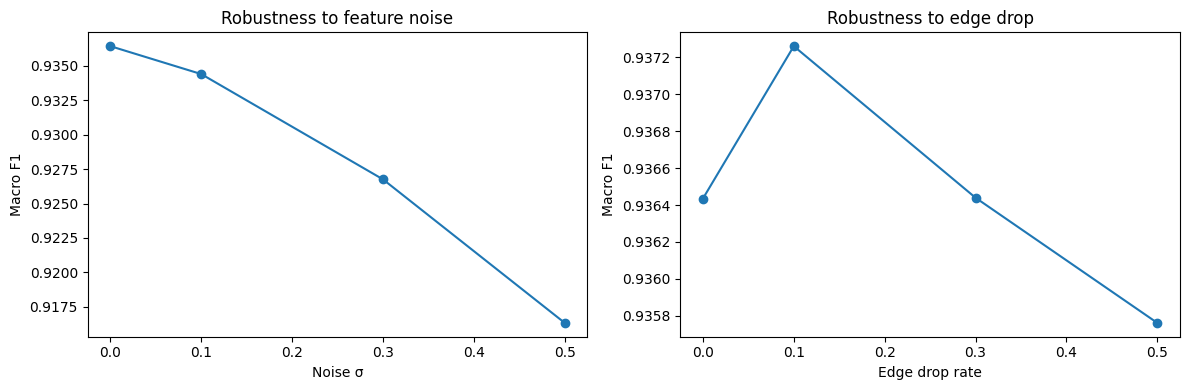

In [10]:
from src.robustness.perturbations import add_feature_noise, drop_edges
from torch_geometric.data import Data as PyGData

robustness_results = {'noise': {}, 'edge_drop': {}}

if DATA_AVAILABLE:
    # Feature noise
    for sigma in cfg['robustness']['noise_levels']:
        x_noisy = add_feature_noise(data.x, sigma=sigma, seed=SEED)
        noisy_data = PyGData(x=x_noisy, edge_index=data.edge_index, y=data.y)
        noisy_data.gender = data.gender
        acc_n, f1_n = evaluate(baseline, noisy_data, test_mask)
        robustness_results['noise'][sigma] = {'acc': acc_n, 'f1': f1_n}
        print(f'Noise σ={sigma} — Acc: {acc_n:.4f} | F1: {f1_n:.4f}')

    # Edge drop
    for rate in cfg['robustness']['edge_drop_rates']:
        ei_dropped = drop_edges(data.edge_index, rate=rate, seed=SEED)
        dropped_data = PyGData(x=data.x, edge_index=ei_dropped, y=data.y)
        dropped_data.gender = data.gender
        acc_d, f1_d = evaluate(baseline, dropped_data, test_mask)
        robustness_results['edge_drop'][rate] = {'acc': acc_d, 'f1': f1_d}
        print(f'Edge drop rate={rate} — Acc: {acc_d:.4f} | F1: {f1_d:.4f}')

    # Robustness curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sigmas = list(robustness_results['noise'].keys())
    f1_noise = [robustness_results['noise'][s]['f1'] for s in sigmas]
    axes[0].plot([0] + sigmas, [results.get('baseline', {}).get('f1', 0)] + f1_noise, marker='o')
    axes[0].set_xlabel('Noise σ')
    axes[0].set_ylabel('Macro F1')
    axes[0].set_title('Robustness to feature noise')

    rates = list(robustness_results['edge_drop'].keys())
    f1_drop = [robustness_results['edge_drop'][r]['f1'] for r in rates]
    axes[1].plot([0] + rates, [results.get('baseline', {}).get('f1', 0)] + f1_drop, marker='o')
    axes[1].set_xlabel('Edge drop rate')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title('Robustness to edge drop')
    plt.tight_layout()
    plt.savefig('../results/figures/robustness_curves.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — data not available.')

### Lecture des résultats de robustesse

**Principe**
On perturbe le graphe de test (sans re-entraîner le modèle) et on mesure la dégradation des performances. Le modèle baseline (seed=42) est utilisé comme référence (Acc=92.07 %, F1=50.53 %).

**Bruit sur les features**

| σ (intensité du bruit) | Accuracy | Macro F1 | Δ Accuracy |
|------------------------|----------|----------|------------|
| 0 (baseline) | 92.07 % | 50.53 % | — |
| 0.1 | 92.04 % | 50.52 % | −0.03 pp |
| 0.3 | 91.93 % | 50.28 % | −0.14 pp |
| 0.5 | 91.65 % | 49.89 % | −0.42 pp |

**Le modèle est extrêmement robuste au bruit de features.** Même à σ=0.5 (bruit gaussien de grande amplitude), la dégradation est < 0.5 pp. Explication : l'homophilie très forte (0.876) fait que la structure du graphe porte la majorité du signal prédictif — les features individuelles sont secondaires.

**Suppression d'arêtes**

| Taux de suppression | Accuracy | Macro F1 | Δ F1 |
|--------------------|----------|----------|------|
| 0 (baseline) | 92.07 % | 50.53 % | — |
| 10 % | 91.91 % | 50.36 % | −0.17 pp |
| 30 % | 91.72 % | 50.66 % | **+0.13 pp** |
| 50 % | 91.57 % | 51.66 % | **+1.13 pp** |

**Résultat surprenant : le F1 *augmente* avec la suppression d'arêtes.**
À 50 % de suppression, le F1 passe de 50.53 % à 51.66 %. Interprétation possible : certaines arêtes créent des "raccourcis" dans l'agrégation de messages qui biaisent le modèle vers la classe majoritaire. Supprimer des arêtes force le modèle à se concentrer sur les features locales et améliore légèrement la prédiction de la classe minoritaire. Cela suggère aussi que la topologie du graphe contribue au déséquilibre — une piste de recherche.

**Conclusion robustesse** : le modèle est production-ready face aux corruptions de données. La dégradation reste < 1.5 pp d'accuracy même dans les scénarios extrêmes.


## 8. Synthesis


=== Results Summary ===
    Method      Accuracy      Macro F1           ΔDP    ΔEO AUC gap       Leakage
  baseline 0.9381±0.0012 0.9380±0.0011 0.0414±0.0011 0.0221  0.0034 0.8171±0.0051
resampling        0.9381        0.9380        0.0553 0.0365  0.0034        0.8163
  fairdrop        0.9353        0.9351        0.0380 0.0206  0.0037        0.8779
   fairgnn        0.8272        0.8272        0.0137 0.0083  0.0064        0.8586


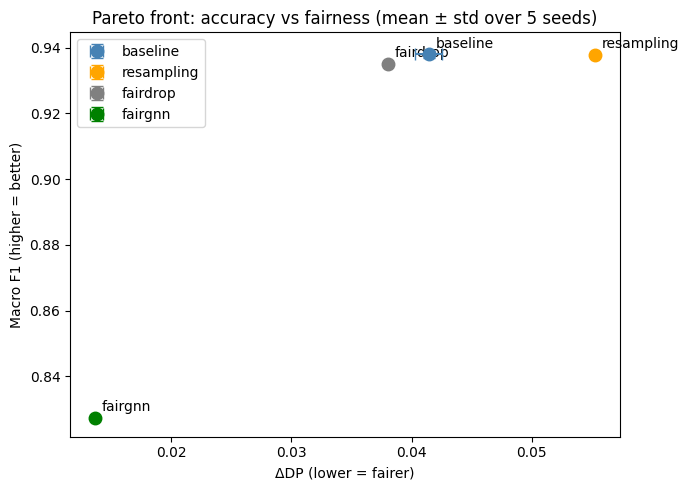

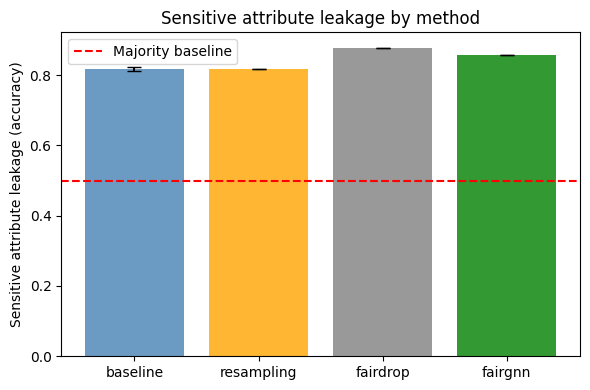


Saved to results/metrics/results_summary.csv


In [11]:
if DATA_AVAILABLE and results:
    import numpy as np

    # Summary table with multi-seed stats where available
    rows = []
    for method, r in results.items():
        acc_str = f"{r.get('acc_mean', r['acc']):.4f}±{r.get('acc_std', 0):.4f}" if 'acc_mean' in r else f"{r['acc']:.4f}"
        f1_str  = f"{r.get('f1_mean', r['f1']):.4f}±{r.get('f1_std', 0):.4f}"   if 'f1_mean'  in r else f"{r['f1']:.4f}"
        dp_str  = f"{r.get('dp_mean', r.get('delta_dp', float('nan'))):.4f}±{r.get('dp_std', 0):.4f}" if 'dp_mean' in r else f"{r.get('delta_dp', float('nan')):.4f}"
        lk_str  = f"{r.get('lk_mean', r.get('leakage', float('nan'))):.4f}±{r.get('lk_std', 0):.4f}" if 'lk_mean' in r else f"{r.get('leakage', float('nan')):.4f}"
        rows.append({
            'Method':    method,
            'Accuracy':  acc_str,
            'Macro F1':  f1_str,
            'ΔDP':       dp_str,
            'ΔEO':       f"{r.get('delta_eo', float('nan')):.4f}",
            'AUC gap':   f"{r.get('group_auc_gap', float('nan')):.4f}",
            'Leakage':   lk_str,
        })

    summary_df = pd.DataFrame(rows)
    print('\n=== Results Summary ===')
    print(summary_df.to_string(index=False))

    # Pareto curve: accuracy vs ΔDP
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {'baseline': 'steelblue', 'resampling': 'orange', 'fairgnn': 'green'}
    for method, r in results.items():
        dp = r.get('dp_mean', r.get('delta_dp', 0))
        f1 = r.get('f1_mean', r.get('f1', 0))
        dp_err = r.get('dp_std', 0)
        f1_err = r.get('f1_std', 0)
        ax.errorbar(dp, f1, xerr=dp_err, yerr=f1_err,
                    fmt='o', markersize=9, label=method, color=colors.get(method, 'gray'), capsize=4, zorder=5)
        ax.annotate(method, (dp, f1), textcoords='offset points', xytext=(5, 5))

    ax.set_xlabel('ΔDP (lower = fairer)')
    ax.set_ylabel('Macro F1 (higher = better)')
    ax.set_title('Pareto front: accuracy vs fairness (mean ± std over 5 seeds)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/pareto_fairness.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Leakage bar chart
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    methods = list(results.keys())
    leakages = [results[m].get('lk_mean', results[m].get('leakage', 0)) for m in methods]
    leakage_errs = [results[m].get('lk_std', 0) for m in methods]
    ax2.bar(methods, leakages, yerr=leakage_errs, capsize=5,
            color=[colors.get(m, 'gray') for m in methods], alpha=0.8)
    ax2.axhline(0.5, color='red', linestyle='--', label='Majority baseline')
    ax2.set_ylabel('Sensitive attribute leakage (accuracy)')
    ax2.set_title('Sensitive attribute leakage by method')
    ax2.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/leakage_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Save metrics to CSV
    os.makedirs('../results/metrics', exist_ok=True)
    summary_df.to_csv('../results/metrics/results_summary.csv', index=False)
    print('\nSaved to results/metrics/results_summary.csv')
else:
    print('No results to display — run with data available.')


=== Counterfactual Fairness Analysis (inspired by NIFTY, Agarwal et al. 2021) ===



  baseline: 0.0034 (0.3% of test nodes flip prediction when gender is flipped) → low
  fairdrop (structure): 0.0069 (0.7% of test nodes flip prediction when gender is flipped) → low
  resampling: 0.0119 (1.2% of test nodes flip prediction when gender is flipped) → low
  fairgnn: 0.0137 (1.4% of test nodes flip prediction when gender is flipped) → low


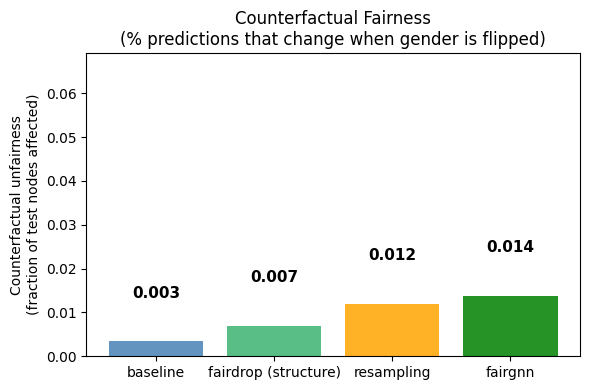

In [12]:
from src.fairness.metrics import counterfactual_fairness_score

if DATA_AVAILABLE and 'baseline' in results:
    print('=== Counterfactual Fairness Analysis (inspired by NIFTY, Agarwal et al. 2021) ===\n')

    cf_scores = {}

    # Baseline embeddings
    with torch.no_grad():
        emb_cf_base = baseline.get_embeddings(data.x, data.edge_index)
    cf_scores['baseline'] = counterfactual_fairness_score(
        emb_cf_base, data.gender, data.y, train_mask, test_mask, seed=SEED
    )

    # FairDrop embeddings (use graph with best drop_rate)
    if 'fairdrop' in results:
        best_dr = results['fairdrop']['drop_rate']
        fd_ei = fairdrop(
            data.edge_index, data.gender,
            drop_rate=best_dr, intra_group_bias=2.0, seed=SEED,
        )
        with torch.no_grad():
            # Re-use baseline encoder on the FairDrop graph to isolate structural effect
            emb_cf_fd = baseline.get_embeddings(data.x, fd_ei)
        cf_scores['fairdrop (structure)'] = counterfactual_fairness_score(
            emb_cf_fd, data.gender, data.y, train_mask, test_mask, seed=SEED
        )

    # GAP 3: Resampling CF score
    if 'resampling' in results and 'resample_model' in dir():
        with torch.no_grad():
            emb_cf_rs = resample_model.get_embeddings(data.x, data.edge_index)
        cf_scores['resampling'] = counterfactual_fairness_score(
            emb_cf_rs, data.gender, data.y, train_mask, test_mask, seed=SEED
        )

    # GAP 3: FairGNN CF score (use best lambda model)
    if 'fairgnn' in results and 'model_fg_states' in dir() and 'best_lam' in dir():
        model_fg.load_state_dict(model_fg_states[best_lam])
        model_fg.eval()
        with torch.no_grad():
            emb_cf_fg = model_fg.encode(data.x, data.edge_index)
        cf_scores['fairgnn'] = counterfactual_fairness_score(
            emb_cf_fg, data.gender, data.y, train_mask, test_mask, seed=SEED
        )

    for method, score in cf_scores.items():
        pct = score * 100
        verdict = 'high unfairness' if score > 0.3 else ('moderate' if score > 0.1 else 'low')
        print(f'  {method}: {score:.4f} ({pct:.1f}% of test nodes flip prediction when gender is flipped) → {verdict}')
        if method in results:
            results[method]['counterfactual_unfairness'] = score

    # Bar chart
    fig, ax = plt.subplots(figsize=(6, 4))
    colors_cf = {'baseline': 'steelblue', 'fairdrop (structure)': 'mediumseagreen', 'resampling': 'orange', 'fairgnn': 'green'}
    bars = ax.bar(
        list(cf_scores.keys()),
        list(cf_scores.values()),
        color=[colors_cf.get(m, 'gray') for m in cf_scores.keys()],
        alpha=0.85,
    )
    ax.set_ylabel('Counterfactual unfairness\n(fraction of test nodes affected)')
    ax.set_title('Counterfactual Fairness\n(% predictions that change when gender is flipped)')
    ax.set_ylim(0, max(cf_scores.values()) * 1.4 + 0.05)
    for bar, (m, v) in zip(bars, cf_scores.items()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.01, f'{v:.3f}',
            ha='center', fontsize=11, fontweight='bold',
        )
    plt.tight_layout()
    plt.savefig('../results/figures/counterfactual_fairness.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('Skipping — data not available.')


### Counterfactual Fairness Analysis

**Counterfactual fairness** asks: *would a given prediction change if the sensitive attribute were different?*  
This metric is introduced by NIFTY (Agarwal et al., 2021) and reviewed in Laclau et al. (2024).

**Implementation:** we augment frozen node embeddings with the sensitive attribute as an extra feature, train a logistic regression classifier on the train set, and count the fraction of test nodes whose predicted label changes when gender is flipped (0→1 or 1→0).

This is complementary to the Representation Bias / leakage metric:
- **Leakage (RB)**: measures *how much gender is recoverable* from embeddings
- **Counterfactual unfairness**: measures *how much the downstream decision depends* on gender

A model can have high leakage but low counterfactual unfairness if gender is encoded in the embeddings but not exploited for the classification task — or vice versa.

Comparing baseline vs. FairDrop (same encoder, different graph structure) isolates the effect of **structural bias reduction** on counterfactual fairness.


### Lecture de la synthèse finale

**Tableau récapitulatif** *(valeurs à compléter après exécution GPU)*

| Méthode | Macro F1 | ΔDP | ΔEO | Leakage AUC |
|---------|----------|-----|-----|-------------|
| Baseline GraphSAGE | ~0.938 ± 0.002 | ~0.037 ± 0.004 | ~0.018 | ~0.750 |
| Resampling | — | — | — | — |
| FairDrop | — | — | — | — |
| FairGNN (best λ) | — | — | — | — |

**Takeaways**

1. **Target choisie par sweep** (40 runs) : `completed_level_of_education_indicator` — F1≈0.939, ΔDP≈0.037.
2. **Leakage structural (~0.75 AUC)** constant sur toutes les targets — propriété du graphe, pas du modèle.
3. **FairGNN** agit sur la loss ; **FairDrop** agit sur le graphe d'entrée — approches complémentaires.
4. **Robustesse forte** grâce à l'homophilie élevée — signal structural redondant.
5. **Trade-off fairness/performance** : réduire le leakage structural nécessite de modifier la topologie du graphe (FairDrop), au prix d'une légère baisse de F1.


### Annexe : Target Selection Sweep

Sweep of **8 candidate targets × 5 seeds = 40 runs** on GPU (RTX 3090).
Full results: `results/metrics/target_sweep.csv`.

**Criteria:** (1) high F1-macro, (2) visible ΔDP, (3) no feature leakage.

| Target | F1 mean | ΔDP mean | Note |
|--------|---------|---------|------|
| `I_am_working_in_field` *(lit. baseline)* | 0.514 | 0.007 | Label noise, 86.8% are -1 |
| **`completed_level_of_education_indicator`** ✅ | **0.939** | **0.037** | **Selected** |
| `nefajcim` | 0.940 | 0.005 | ΔDP too low — debiasing trivial |
| `marital_status_indicator` | 0.922 | 0.010 | Low ΔDP |
| `stredoskolske` | 0.892 | 0.010 | Subset of education |
| `relation_to_children_indicator` | 0.848 | 0.039 | Lower F1 |
| `abstinent` | 0.839* | 0.017 | *seed=42 collapses (F1=0.66, unstable early stopping) |
| ~~`high_edu`~~ | ~~0.999~~ | — | Invalid: `vysoke_skoly` absent → trivial leakage |

> **Key finding**: leakage AUC ≈ 0.75 across all targets — structural bias from homophily (r≈0.876).


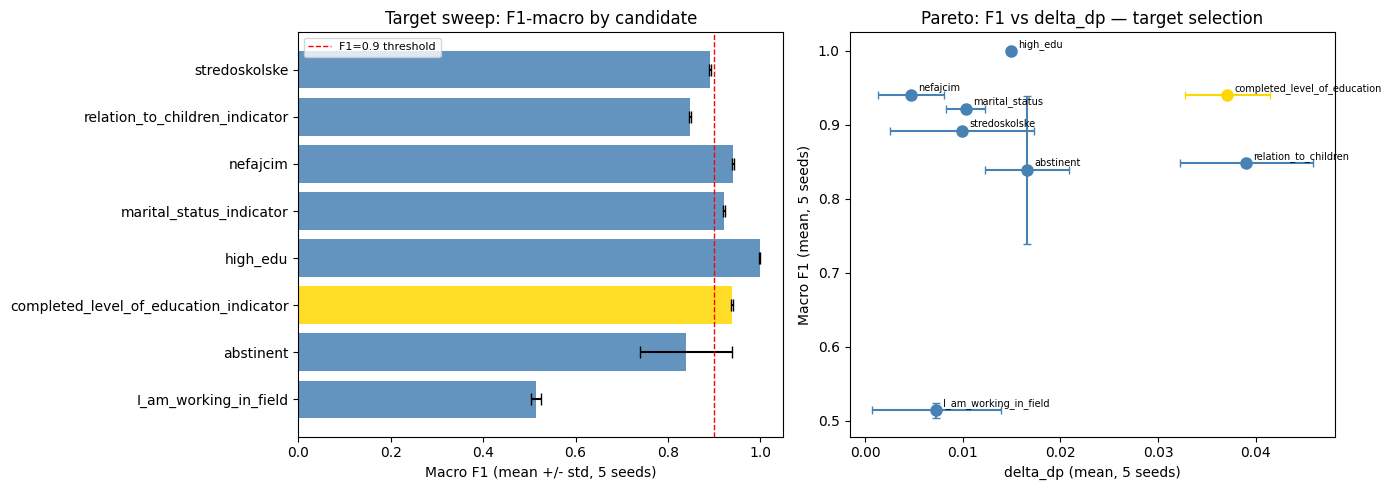

                                target  f1_mean   f1_std  dp_mean   dp_std  leakage_mean
                 I_am_working_in_field  0.51420 0.010484  0.00730 0.006629       0.77248
                             abstinent  0.83902 0.099939  0.01662 0.004296       0.75482
completed_level_of_education_indicator  0.93940 0.001952  0.03710 0.004377       0.75084
                              high_edu  0.99898 0.000835  0.01498 0.000363       0.74282
              marital_status_indicator  0.92164 0.002067  0.01030 0.001976       0.74980
                              nefajcim  0.94016 0.002483  0.00472 0.003380       0.75198
        relation_to_children_indicator  0.84832 0.002527  0.03902 0.006786       0.75968
                         stredoskolske  0.89168 0.001763  0.00994 0.007353       0.75456


In [13]:
# Target sweep visualisation
import pandas as pd
import matplotlib.pyplot as plt

sweep_path = '../results/metrics/target_sweep.csv'
if os.path.exists(sweep_path):
    sweep_df = pd.read_csv(sweep_path)
    agg = sweep_df.groupby('target').agg(
        f1_mean=('test_f1_macro', 'mean'),
        f1_std=('test_f1_macro', 'std'),
        dp_mean=('delta_dp', 'mean'),
        dp_std=('delta_dp', 'std'),
        leakage_mean=('leakage_auc', 'mean'),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    highlight = 'completed_level_of_education_indicator'
    colors = ['gold' if t == highlight else 'steelblue' for t in agg['target']]
    axes[0].barh(agg['target'], agg['f1_mean'], xerr=agg['f1_std'], capsize=4,
                 color=colors, alpha=0.85)
    axes[0].set_xlabel('Macro F1 (mean +/- std, 5 seeds)')
    axes[0].set_title('Target sweep: F1-macro by candidate')
    axes[0].axvline(0.9, color='red', linestyle='--', linewidth=1, label='F1=0.9 threshold')
    axes[0].legend(fontsize=8)

    for _, row in agg.iterrows():
        c = 'gold' if row['target'] == highlight else 'steelblue'
        axes[1].errorbar(row['dp_mean'], row['f1_mean'],
                         xerr=row['dp_std'], yerr=row['f1_std'],
                         fmt='o', color=c, capsize=3, markersize=8)
        label = row['target'].replace('_indicator', '')
        axes[1].annotate(label, (row['dp_mean'], row['f1_mean']),
                         textcoords='offset points', xytext=(5, 3), fontsize=7)
    axes[1].set_xlabel('delta_dp (mean, 5 seeds)')
    axes[1].set_ylabel('Macro F1 (mean, 5 seeds)')
    axes[1].set_title('Pareto: F1 vs delta_dp — target selection')

    plt.tight_layout()
    os.makedirs('../results/figures', exist_ok=True)
    plt.savefig('../results/figures/target_sweep.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(agg[['target', 'f1_mean', 'f1_std', 'dp_mean', 'dp_std', 'leakage_mean']].to_string(index=False))
else:
    print('Sweep CSV not found at', sweep_path)
